In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from jupyterthemes import jtplot
jtplot.reset()

In [2]:
results = {
    '1': (0.2404, 0.2369, [0.232399, 0.231683, 0.23115, 0.232017, 0.232102]),
    '10': (0.2403, 0.2369, [0.232345, 0.23157, 0.23105, 0.231974, 0.232035]),
    '100': (0.2404, 0.2370, [0.232296, 0.231484, 0.230965, 0.231872, 0.23205]),
    '1000': (0.2404, 0.2370, [0.232358, 0.231586, 0.231198, 0.2319, 0.23202]),
    '10000': (0.2404, 0.2369, [0.232321, 0.23153, 0.231076, 0.231793, 0.231924]),
    
}

baseline = {
    'Private': 0.2407,
    'Public': 0.2371,
    'Cross-Validation': np.mean([0.232183, 0.231928, 0.231461, 0.231987, 0.232258])
}

print()

df = []
for k,v in results.items():
    df.append(pd.DataFrame({
        'Effective Sample Size': k,
        'Validation Dataset': ['Private', 'Public', 'Cross-Validation'],
        'RMSE': [v[0], v[1], np.mean(v[2])],
        'Baseline Improvement (RMSE)': [
            baseline['Private'] - v[0],
            baseline['Public'] - v[1],
            baseline['Cross-Validation'] - np.mean(v[2]),
        ],        
        'Baseline Improvement (%) ': [
            100*(baseline['Private'] - v[0])/baseline['Private'],
            100*(baseline['Public'] - v[1])/baseline['Public'],
            100*(baseline['Cross-Validation'] - np.mean(v[2]))/baseline['Cross-Validation'],
        ]
    }))
df = pd.concat(df, 0)
df

,Effective Sample Size,Validation Dataset,RMSE,Baseline Improvement (RMSE),Baseline Improvement (%)
0,1,Private,0.240400,0.000300,0.124636
1,1,Public,0.236900,0.000200,0.084353
2,1,Cross-Validation,0.231870,0.000093,0.040179
0,10,Private,0.240300,0.000400,0.166182
1,10,Public,0.236900,0.000200,0.084353
2,10,Cross-Validation,0.231795,0.000169,0.072684
0,100,Private,0.240400,0.000300,0.124636
1,100,Public,0.237000,0.000100,0.042176
2,100,Cross-Validation,0.231733,0.000230,0.099154
0,1000,Private,0.240400,0.000300,0.124636


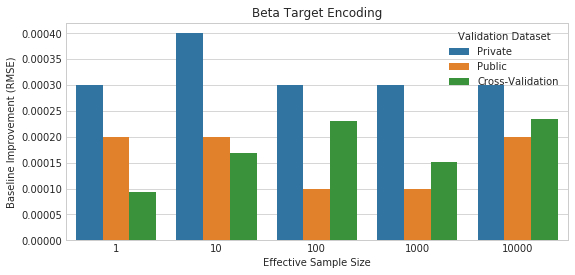

In [3]:
import seaborn as sns
sns.set_style('whitegrid')
fig = plt.figure(figsize=(9, 4))
ax = sns.barplot(
    x = 'Effective Sample Size',
    y = 'Baseline Improvement (RMSE)', 
    hue = 'Validation Dataset',
    data = df
)
plt.title('Beta Target Encoding')
plt.savefig("../content/images/bayesian-mean-target-encoding.svg", format="svg")
plt.show()